In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv('../data/shipments.csv')

df.head()

,Distance_km,Transport_Mode,Weather,Traffic_Level,Fuel_Price,Carrier_Rating,Warehouse_Time_hr,Delivery_Delay_hr
0,910,Truck,Clear,High,110.156208,1.4,36,29.68
1,1344,Air,Storm,High,91.333699,2.7,17,37.40
2,1180,Air,Storm,Medium,101.745712,1.9,46,47.14
3,1145,Air,Fog,Low,112.814966,2.0,15,8.75
4,1688,Truck,Rainy,Low,94.530484,3.0,39,22.89


In [3]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.head()

,Distance_km,Fuel_Price,Carrier_Rating,Warehouse_Time_hr,Delivery_Delay_hr,Transport_Mode_Rail,Transport_Mode_Ship,Transport_Mode_Truck,Weather_Fog,Weather_Rainy,Weather_Storm,Traffic_Level_Low,Traffic_Level_Medium
0,910,110.156208,1.4,36,29.68,False,False,True,False,False,False,False,False
1,1344,91.333699,2.7,17,37.40,False,False,False,False,False,True,False,False
2,1180,101.745712,1.9,46,47.14,False,False,False,False,False,True,False,True
3,1145,112.814966,2.0,15,8.75,False,False,False,True,False,False,True,False
4,1688,94.530484,3.0,39,22.89,False,False,True,False,True,False,True,False


In [4]:
X = df_encoded.drop(
    'Delivery_Delay_hr',
    axis=1
)

y = df_encoded['Delivery_Delay_hr']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [7]:
predictions = model.predict(X_test)

In [8]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", round(mae, 2))

print("RMSE:", round(rmse, 2))

print("R2 Score:", round(r2, 2))

MAE: 4.33
RMSE: 5.38
R2 Score: 0.84


In [9]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
0,Distance_km,0.429279
3,Warehouse_Time_hr,0.289067
9,Weather_Storm,0.107615
2,Carrier_Rating,0.063347
1,Fuel_Price,0.036827
11,Traffic_Level_Medium,0.027051
10,Traffic_Level_Low,0.026282
6,Transport_Mode_Truck,0.004737
4,Transport_Mode_Rail,0.004588
5,Transport_Mode_Ship,0.004291


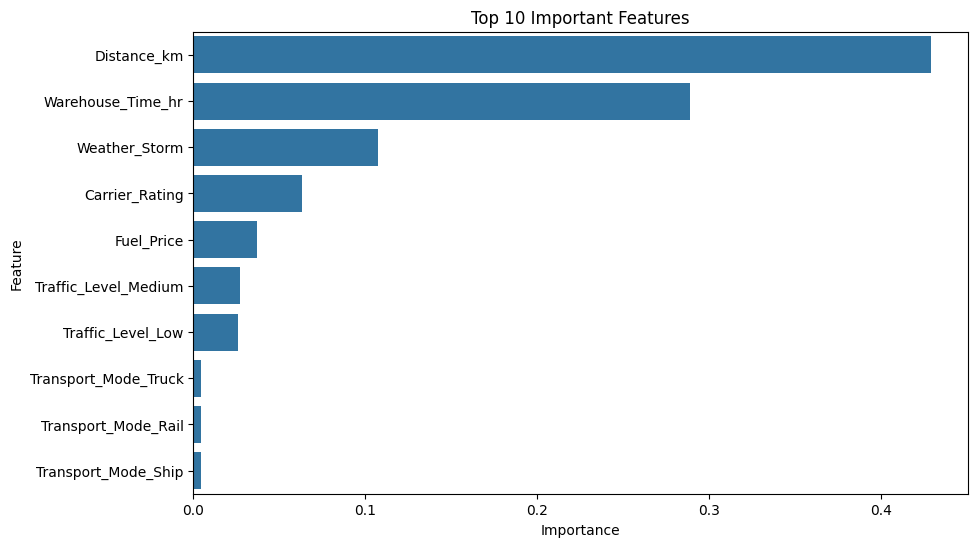

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Important Features')

plt.show()

In [11]:
joblib.dump(
    model,
    '../models/random_forest.pkl'
)

print("Model saved successfully!")

Model saved successfully!
